# Figure 2
## Annual Trends of Economic Burden in World

### ver 1

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

plt.rcParams["font.family"] = "Helvetica"

In [62]:
annual_agg = pd.read_csv('results/annual_imputation_aggregate_ALL.csv')
print(annual_agg.head())

gdp = pd.read_csv('data/GDP_ppp.csv')
gdp_world = (
    gdp.sum(axis=0, numeric_only=True)
      .rename_axis('year')
      .reset_index(name='GDP')
)
# gdp_world.name = 'World'
gdp_world.head()

  aggregate_level aggregate_name disease scenario  year      GDP_loss
0           World          World   ASCVD    lower  2020  2.143460e+10
1           World          World   ASCVD    lower  2021  5.803654e+10
2           World          World   ASCVD    lower  2022  1.079380e+11
3           World          World   ASCVD    lower  2023  1.460406e+11
4           World          World   ASCVD    lower  2024  1.815837e+11


,year,GDP
0,2010,9.457784e+13
1,2011,9.823437e+13
2,2012,1.013112e+14
3,2013,1.046387e+14
4,2014,1.082074e+14


In [98]:
annual_agg['aggregate_name'].unique()

array(['World', 'East Asia and Pacific', 'Europe and Central Asia',
       'Latin America and Caribbean', 'Middle East and North Africa',
       'North America', 'South Asia', 'Sub-Saharan Africa'], dtype=object)

In [70]:
world_df = annual_agg[(annual_agg['aggregate_name']=='World') 
                      & (annual_agg['disease']=='ASCVD') 
                      & (annual_agg['scenario'] == 'val')].sort_values('year').reset_index(drop=True).copy()
world_df = pd.concat([pd.DataFrame({'year': [2019], 'aggregate_name': 'World', 'disease': 'ASCVD', 'GDP_loss': [0]}), world_df], ignore_index=True)

world_df['year'] = pd.to_numeric(world_df['year'], errors='coerce').astype('Int64')
gdp_world['year'] = pd.to_numeric(gdp_world['year'], errors='coerce').astype('Int64')

world = world_df.merge(gdp_world, on='year', how='left')
world['GDP_CF'] = world['GDP_loss'] + world['GDP']
world.drop(columns=['aggregate_level', 'scenario'], inplace=True)
world.rename(columns={'aggregate_name': 'Country', 'GDP': 'GDP_SQ'}, inplace=True)
world

,year,Country,disease,GDP_loss,GDP_SQ,GDP_CF
0,2019,World,ASCVD,0.000000e+00,1.277480e+14,1.277480e+14
1,2020,World,ASCVD,3.082315e+10,1.235705e+14,1.236013e+14
2,2021,World,ASCVD,7.068353e+10,1.197483e+14,1.198189e+14
3,2022,World,ASCVD,1.287941e+11,1.268618e+14,1.269906e+14
4,2023,World,ASCVD,1.742575e+11,1.312260e+14,1.314003e+14
5,2024,World,ASCVD,2.168636e+11,1.357066e+14,1.359234e+14
6,2025,World,ASCVD,2.658096e+11,1.402133e+14,1.404791e+14
7,2026,World,ASCVD,3.024431e+11,1.448768e+14,1.451793e+14
8,2027,World,ASCVD,3.470479e+11,1.496361e+14,1.499832e+14
9,2028,World,ASCVD,3.842759e+11,1.544870e+14,1.548713e+14


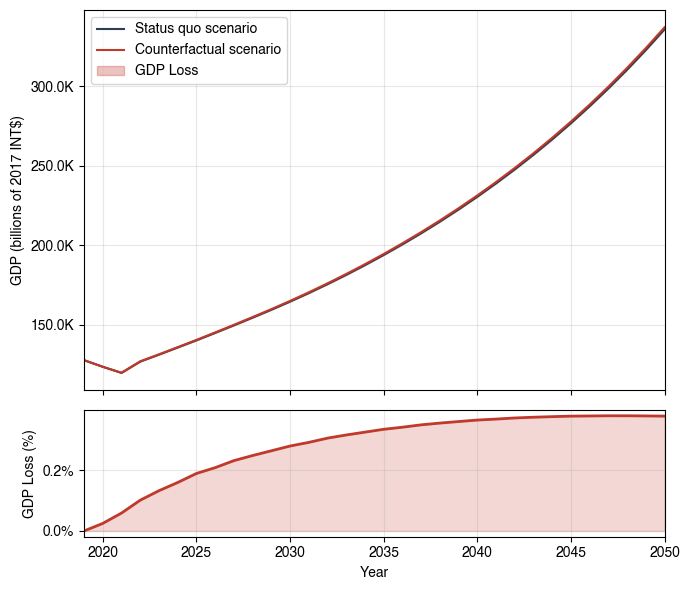

In [96]:
years = world['year'].values
sq = world['GDP_SQ'].values / 1e9
cf = world['GDP_CF'].values / 1e9

# bd = world['GDP_loss'].values * 100 / 1e9
loss_pct = (world['GDP_loss'].values / world['GDP_SQ'].values) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax1.plot(years, sq, color='#2c3e50', linewidth=1.5, label='Status quo scenario')
ax1.plot(years, cf, color='#c0392b', linewidth=1.5, label='Counterfactual scenario')
# ax1.plot(years, bd, color='#f1bf4f', linewidth=1.5, label='GDP Loss')
ax1.fill_between(years, sq, cf, alpha=0.3, color='#c0392b', label='GDP Loss')
ax1.set_ylabel('GDP (billions of 2017 INT$)')
# ax1.set_ylim(bottom=sq.min() * 0.98)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e3:.1f}K'))
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

ax2.plot(years, loss_pct, color="#c0392b", linewidth=2)
ax2.fill_between(years, 0, loss_pct, alpha=0.2, color='#c0392b')
ax2.set_xlabel('Year')
ax2.set_ylabel('GDP Loss (%)')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax2.set_xlim(2019, 2050)
ax2.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('figures/figure_3.png', dpi=900, bbox_inches='tight')
# plt.savefig('figures/figure_3.pdf', bbox_inches='tight')
# plt.savefig('figures/figure_3.svg', bbox_inches='tight')
plt.show()

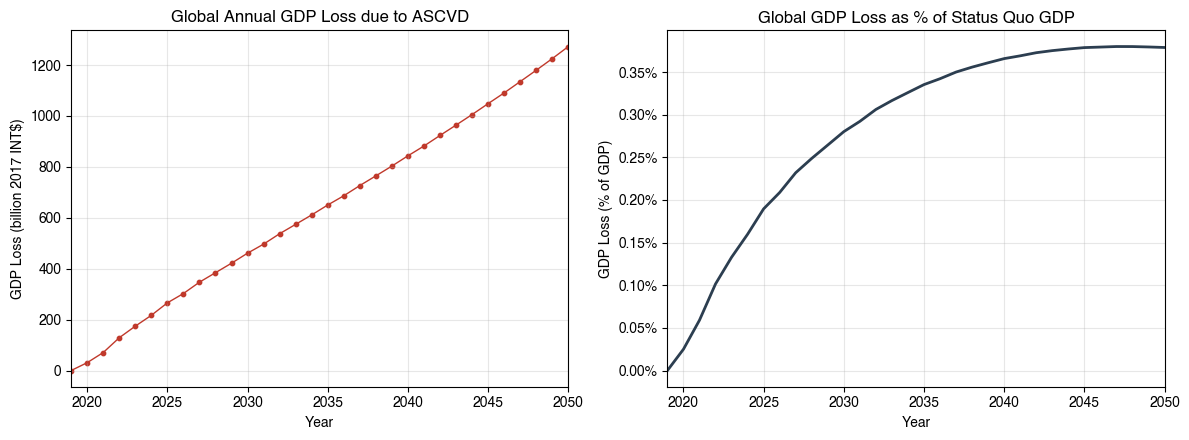

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

years = world['year'].values

loss_billion = world['GDP_loss'].values / 1e9
axes[0].plot(years, loss_billion, color='#c0392b', linewidth=1)
axes[0].scatter(years, loss_billion, color='#c0392b', s=10)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('GDP Loss (billion 2017 INT$)')
axes[0].set_title('Global Annual GDP Loss due to ASCVD')
axes[0].set_xlim(2019, 2050)
axes[0].grid(alpha=0.3)

loss_pct = (world['GDP_loss'].values / world['GDP_SQ'].values) * 100
axes[1].plot(years, loss_pct, color='#2c3e50', linewidth=2)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('GDP Loss (% of GDP)')
axes[1].set_title('Global GDP Loss as % of Status Quo GDP')
axes[1].set_xlim(2019, 2050)
axes[1].grid(alpha=0.3)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

plt.tight_layout()
# plt.savefig('tables/usa_gdp_loss_detail.png', dpi=300, bbox_inches='tight')
plt.show()

### ver 2

In [170]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import Formatter

plt.rcParams["font.family"] = "Helvetica"

In [197]:
class ScaledWordFormatter(Formatter):
    def __init__(self, scale=1.0, label=None):
        self.scale = scale
        self.label = label or ""

    def __call__(self, x, pos=None):
        return f"{x / self.scale:.1f}"

    def get_offset(self):
        return self.label


def choose_axis_scale(max_abs_value):
    if pd.isna(max_abs_value):
        return 1.0, None
    v = abs(float(max_abs_value))
    if v >= 1e12:
        return 1e12, "trillions"
    if v >= 1e9:
        return 1e9, "billions"
    if v >= 1e6:
        return 1e6, "millions"
    if v >= 1e3:
        return 1e3, "thousands"
    return 1.0, None


def plot_aggregate(
    annual_df,
    out_pdf="figures/figure_S2_aggregate_world_big.pdf",
    disease="ASCVD",
    id_col="aggregate_name",
    level_col="aggregate_level",
    x_col="year",
    y_col="GDP_loss",
    scenario_col="scenario",
    disease_col="disease",
    world_name="World",
    region_order=None,
    save=True,
):
    if isinstance(annual_df, str):
        df = pd.read_excel(annual_df) if annual_df.lower().endswith(".xlsx") else pd.read_csv(annual_df)
    else:
        df = annual_df.copy()

    required = [id_col, level_col, x_col, y_col, scenario_col, disease_col]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")

    df = df[df[disease_col].astype(str) == str(disease)].copy()
    df = df.dropna(subset=[id_col, level_col, x_col, y_col, scenario_col]).copy()

    df[id_col] = df[id_col].astype(str).str.strip()
    df[level_col] = df[level_col].astype(str).str.strip()
    df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    df[y_col] = pd.to_numeric(df[y_col], errors="coerce")

    scenario_alias = {
        "val": "val", "value": "val", "mean": "val",
        "lower": "lower", "lwr": "lower", "low": "lower", "lb": "lower",
        "upper": "upper", "upr": "upper", "up": "upper", "ub": "upper",
    }
    df[scenario_col] = (
        df[scenario_col].astype(str).str.strip().str.lower()
        .map(lambda x: scenario_alias.get(x, x))
    )

    df = df.dropna(subset=[x_col, y_col]).copy()
    df[x_col] = df[x_col].astype(int)

    names = sorted(df[id_col].unique())
    if world_name not in names:
        world_rows = df[df[level_col].str.lower() == "world"]
        if world_rows.empty:
            raise ValueError("World aggregate not found.")
        world_name = world_rows[id_col].iloc[0]

    regions = [n for n in names if n != world_name]

    if region_order is None:
        region_order = [
            "East Asia and Pacific",
            "Europe and Central Asia",
            "Latin America and Caribbean",
            "Middle East and North Africa",
            "North America",
            "South Asia",
            "Sub-Saharan Africa",
        ]
    ordered = [r for r in region_order if r in regions]
    ordered += [r for r in regions if r not in ordered]
    regions = ordered[:7]

    def _plot_panel(ax, group_name):
        sub = df[df[id_col] == group_name].copy()
        if sub.empty:
            ax.set_visible(False)
            return

        wide = (
            sub.pivot_table(index=x_col, columns=scenario_col, values=y_col, aggfunc="mean")
            .reset_index()
            .sort_values(x_col)
        )
        wide.columns.name = None

        val_series = None
        if "val" in wide.columns:
            val_series = wide["val"]
        elif ("lower" in wide.columns) and ("upper" in wide.columns):
            val_series = (wide["lower"] + wide["upper"]) / 2.0

        line_color = "#c53a32" if group_name == world_name else "#2c3e50"

        if val_series is not None:
            lw = 1.8 if group_name == world_name else 1.4
            ax.plot(wide[x_col], val_series, linewidth=lw, color=line_color)

        if ("lower" in wide.columns) and ("upper" in wide.columns):
            band_df = wide.dropna(subset=["lower", "upper"])
            if not band_df.empty:
                ax.fill_between(
                    band_df[x_col].to_numpy(),
                    band_df["lower"].to_numpy(),
                    band_df["upper"].to_numpy(),
                    color=line_color,
                    alpha=0.22,
                    linewidth=0,
                )

        y_candidates = []
        for cn in ["lower", "val", "upper"]:
            if cn in wide.columns:
                y_candidates.extend(wide[cn].dropna().tolist())
        max_abs = np.max(np.abs(y_candidates)) if y_candidates else np.nan

        scale, scale_label = choose_axis_scale(max_abs)
        ax.yaxis.set_major_formatter(ScaledWordFormatter(scale=scale, label=scale_label))
        ax.yaxis.get_offset_text().set_visible(bool(scale_label))
        ax.yaxis.get_offset_text().set_size(9 if group_name == world_name else 8)

        ax.set_title(group_name, fontsize=13, pad=4)
        ax.tick_params(axis="both", labelsize=9)
        ax.grid(alpha=0.2)
        ax.margins(0.025)

    out_dir = os.path.dirname(out_pdf)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    plt.rcParams["font.family"] = "Helvetica"
    plt.rcParams["axes.unicode_minus"] = False

    with PdfPages(out_pdf) as pdf:
        fig = plt.figure(figsize=(18, 9), constrained_layout=False)

        ncols, nrows = 4, 3
        L, R, B, T = 0.06, 0.03, 0.08, 0.05
        gx, gy = 0.03, 0.06
        cw = (1 - L - R - (ncols - 1) * gx) / ncols
        rh = (1 - B - T - (nrows - 1) * gy) / nrows

        def box(col, row, colspan=1, rowspan=1):
            x = L + col * (cw + gx)
            y = B + (nrows - row - rowspan) * (rh + gy)
            w = colspan * cw + (colspan - 1) * gx
            h = rowspan * rh + (rowspan - 1) * gy
            return [x, y, w, h]

        ax_world = fig.add_axes(box(0, 0, colspan=2, rowspan=2))
        _plot_panel(ax_world, world_name)

        b1 = box(2, 0)  # row1 col3
        b2 = box(3, 0)  # row1 col4
        b3 = box(2, 1)  # row2 col3
        b4 = box(3, 1) 

        y_bottom = B 
        h_bottom = rh
        w_bottom = cw

        x5 = L + 0.5 * (cw + gx)
        x6 = L + 1 * (cw + gx) + 0.5 * (cw + gx)
        x7 = L + 2 * (cw + gx) + 0.5 * (cw + gx)

        b5 = [x5, y_bottom, w_bottom, h_bottom]
        b6 = [x6, y_bottom, w_bottom, h_bottom]
        b7 = [x7, y_bottom, w_bottom, h_bottom]

        region_boxes = [b1, b2, b3, b4, b5, b6, b7]

        for i, reg in enumerate(regions):
            ax = fig.add_axes(region_boxes[i])
            _plot_panel(ax, reg)

        fig.text(0.5, 0.035, "Year", ha="center", va="center", fontsize=14)
        fig.text(
            0.035, 0.5, "Annual GDP loss (2017 INT$)",
            ha="center", va="center", rotation="vertical", fontsize=14
        )
        plt.tight_layout()
        if save :
            pdf.savefig(fig, dpi=900, bbox_inches='tight', pad_inches=0.02)
            plt.show()
            plt.close(fig)
        else:
            plt.show()

    return out_pdf

/var/folders/wr/xk9rgnjn4fsf4_0_z7zw3bcm0000gn/T/ipykernel_27502/794581902.py:203: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


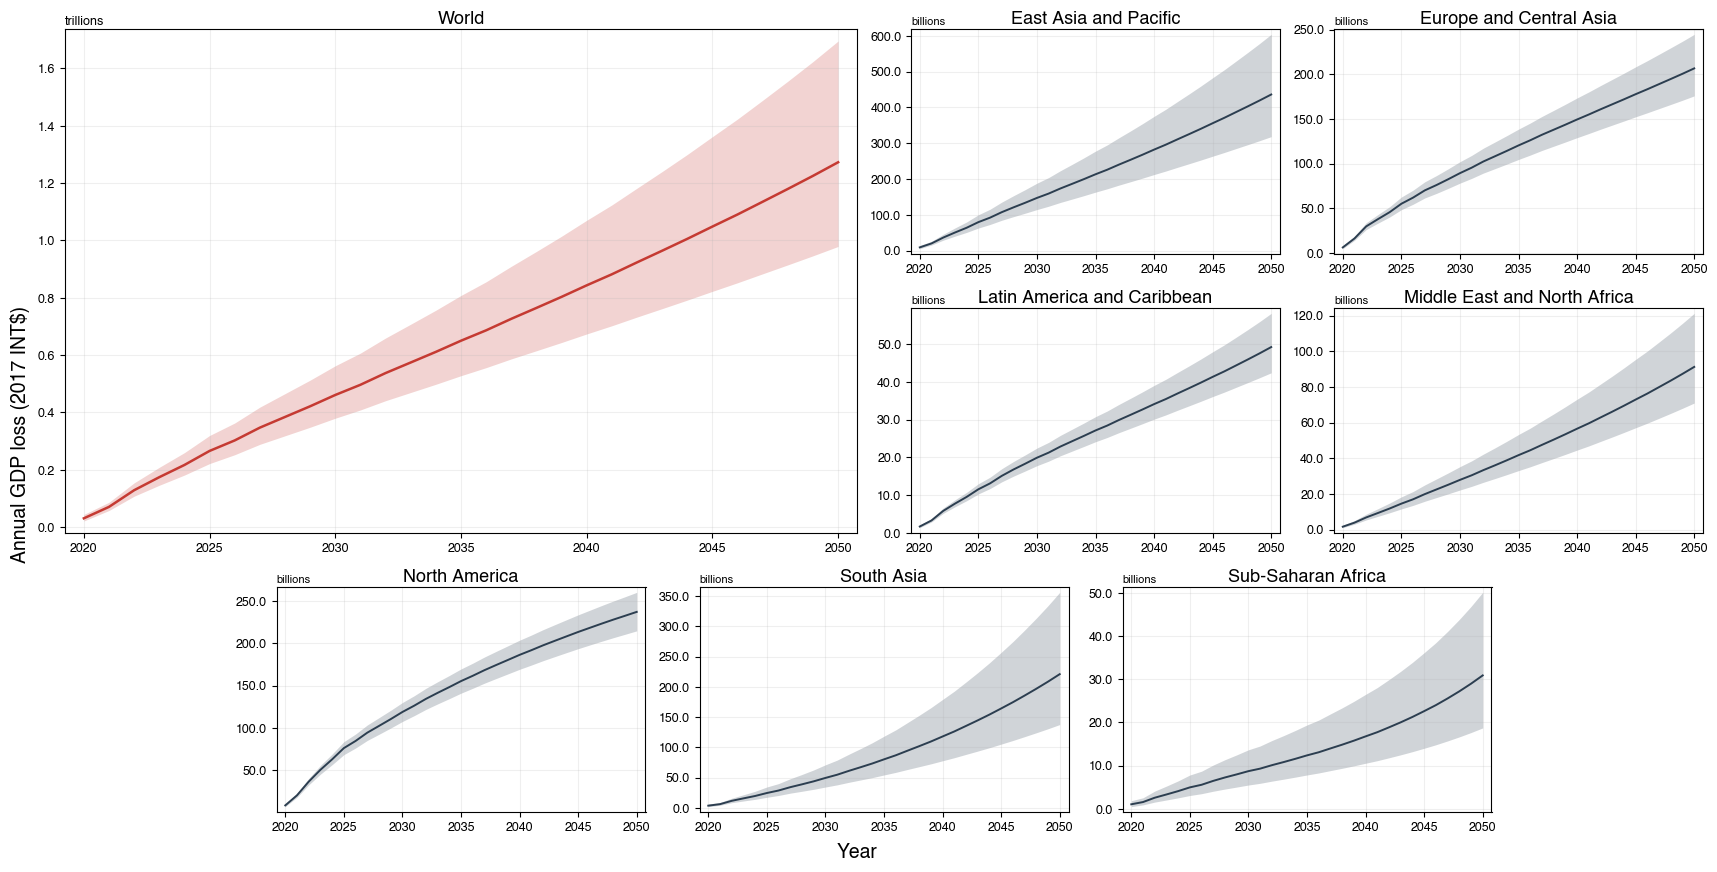

'figures/figure_2.pdf'

In [198]:
plot_aggregate(
    annual_df="results/annual_imputation_aggregate_ALL.csv",
    disease="ASCVD",
    out_pdf="figures/figure_2.pdf",
    save=True,
)

# Supplementary Figures 2
## Annual Trends of Economic Burden by Countries, Diseases

In [191]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import Formatter

In [192]:
class ScaledWordFormatter(Formatter):
    def __init__(self, scale=1.0, label=None):
        self.scale = scale
        self.label = label or ""

    def __call__(self, x, pos=None):
        return f"{x / self.scale:.1f}"

    def get_offset(self):
        return self.label

DISEASE_LABEL_BY_TAG = {
    'IHD': 'Ischemic heart disease',
    'IS': 'Ischemic stroke',
    'PAD': 'Lower extremity peripheral arterial disease',
    'ALL': 'ASCVD',
}

PLOT_TAG_BY_DISEASE = {
    'Ischemic heart disease': 'IHD',
    'Ischemic stroke': 'IS',
    'Lower extremity peripheral arterial disease': 'PAD',
    'ASCVD': 'ASCVD',
}

def safe_token(text):
    return re.sub(r'[^A-Za-z0-9]+', '_', str(text)).strip('_')

def first_existing_path(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f'No file found among candidates: {paths}')

def choose_axis_scale(max_abs_value):
    if pd.isna(max_abs_value):
        return 1.0, None
    v = abs(float(max_abs_value))
    if v >= 1e9:
        return 1e9, 'bilions'
    if v >= 1e6:
        return 1e6, 'milions'
    if v >= 1e3:
        return 1e3, 'thousands'
    return 1.0, None

def load_table(path):
    if path.lower().endswith('.xlsx'):
        return pd.read_excel(path)
    return pd.read_csv(path)

def build_observed_country_map(disease_option='ALL', annual_results_dir='results'):
    disease_option = str(disease_option).strip().upper()
    if disease_option not in {'ALL','IHD','IS','PAD'}:
        raise ValueError('disease_option must be ALL/IHD/IS/PAD')

    tags = ['IHD', 'IS', 'PAD', 'ALL'] if disease_option == 'ALL' else [disease_option]
    observed_by_disease = {}

    for tag in tags:
        annual_file = os.path.join(annual_results_dir, f'annual_results_{tag}.csv')
        
        df = pd.read_csv(annual_file)
        df = df[df["Country Code"] != "ROU"].copy()

        if tag == 'ALL':
            observed_by_disease['ASCVD'] = set(df['Country Code'].dropna().astype(str).unique())
        else:
            disease_label = DISEASE_LABEL_BY_TAG[tag]
            if 'disease' in df.columns:
                dff = df[df['disease'] == disease_label].copy()
            else:
                dff = df.copy()
            observed_by_disease[disease_label] = set(dff['Country Code'].dropna().astype(str).unique())

    return observed_by_disease

def plot_all_countries(
    annual_df,
    missing_countries,
    out_pdf='figures/figure_S2_plot.pdf',
    ncols=4,
    nrows=6,
    id_col='Country Code',
    x_col='year',
    y_col='GDP_loss',
    scenario_col='scenario',
    disease=None,
    disease_col='disease',
    sort=True,
    sharey=False,
    save=True,
):
    df = annual_df.copy()

    required_cols = [id_col, x_col, y_col, scenario_col]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f'Missing required column: {col}')

    if disease is not None:
        if disease_col not in df.columns:
            raise ValueError(f"disease filter requested, but '{disease_col}' not found")
        df = df[df[disease_col] == disease].copy()

    df = df.dropna(subset=[id_col, x_col, y_col, scenario_col]).copy()
    df[x_col] = df[x_col].astype(int)

    missing_countries = set(missing_countries)
    countries = df[id_col].dropna().unique()
    if sort:
        countries = sorted(countries)

    per_page = ncols * nrows
    out_dir = os.path.dirname(out_pdf)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    plt.rcParams['font.family'] = 'Helvetica'
    plt.rcParams['axes.unicode_minus'] = False

    with PdfPages(out_pdf) as pdf:
        for start in range(0, len(countries), per_page):
            chunk = countries[start:start + per_page]

            nrows_ = int(np.ceil(len(chunk) / ncols))
            fig, axes = plt.subplots(
                nrows=nrows_,
                ncols=ncols,
                figsize=(16, 10* (nrows_ / nrows)),
                sharex=True,
                sharey=sharey
            )
            axes = np.array(axes).reshape(-1)

            for i, c in enumerate(chunk):
                ax = axes[i]
                sub = df[df[id_col] == c].copy()
                if sub.empty:
                    ax.set_visible(False)
                    continue

                wide = (
                    sub.pivot_table(index=x_col, columns=scenario_col, values=y_col, aggfunc='mean')
                    .reset_index()
                    .sort_values(x_col)
                )

                is_missing = c in missing_countries
                line_color = '#c53a32' if is_missing else '#2c3e50'
                band_color = '#c53a32' if is_missing else '#2c3e50'

                if 'val' in wide.columns:
                    ax.plot(wide[x_col], wide['val'], linewidth=1.4, color=line_color)

                if ('lower' in wide.columns) and ('upper' in wide.columns):
                    band_df = wide.dropna(subset=['lower', 'upper']).copy()
                    if not band_df.empty:
                        ax.fill_between(
                            band_df[x_col],
                            band_df['lower'],
                            band_df['upper'],
                            color=band_color,
                            alpha=0.25,
                            linewidth=0,
                        )

                y_candidates = []
                for c_name in ['lower', 'val', 'upper']:
                    if c_name in wide.columns:
                        y_candidates.extend(wide[c_name].dropna().tolist())
                max_abs = np.max(np.abs(y_candidates)) if len(y_candidates) > 0 else np.nan
                scale, scale_label = choose_axis_scale(max_abs)
                fmt = ScaledWordFormatter(scale=scale, label=scale_label)
                ax.yaxis.set_major_formatter(fmt)
                
                # Put unit words at the same location where scientific offset text (e.g., 1e6) appears.
                offset_text = ax.yaxis.get_offset_text()
                offset_text.set_visible(bool(scale_label))
                offset_text.set_size(8)

                ax.set_title(str(c), fontsize=9)
                ax.tick_params(axis='both', labelsize=7)
                ax.grid(alpha=0.2)

                if is_missing:
                    ax.text(0.98, 0.95, 'Imputed', transform=ax.transAxes, ha='right', va='top', fontsize=7, color='#c53a32')
                else:
                    ax.text(0.98, 0.95, 'Observed', transform=ax.transAxes, ha='right', va='top', fontsize=7, color='#2c3e50')
                    
                ax.margins(0.025)

            for j in range(len(chunk), len(axes)):
                fig.delaxes(axes[j])

            # fig.supxlabel('Year', fontsize=11)
            # fig.supylabel('Annual GDP loss (2017 INT$)', fontsize=11, x=0.02)
            # plt.tight_layout(rect=[0.01, 0, 1, 0.95])
            
            fig.tight_layout(rect=[0.02, 0.04, 0.99, 0.98])

            used_axes = [ax for ax in fig.axes if ax.get_visible()]
            fig.canvas.draw()
            boxes = [ax.get_position() for ax in used_axes]

            left = min(b.x0 for b in boxes)
            right = max(b.x1 for b in boxes)
            bottom = min(b.y0 for b in boxes)
            top = max(b.y1 for b in boxes)

            fig.text((left + right) / 2, 0.04, 'Year',
                    ha='center', va='top', fontsize=11)
            fig.text(left - 0.03, (bottom + top) / 2, 'Annual GDP loss (2017 INT$)',
                    ha='center', va='center', rotation='vertical', fontsize=11)

            if save:
                pdf.savefig(fig, dpi=900, bbox_inches='tight', pad_inches=0.02)
                plt.close(fig)
            else:
                plt.show()

    return out_pdf

In [193]:
SAVE = True
DISEASE_OPTION = ['ALL', 'IHD', 'IS', 'PAD']  # ALL / IHD / IS / PAD
ANNUAL_RESULTS_DIR = 'results'
OUTPUT_DIR = 'figures'
NROWS = 6
NCOLS = 4
SHAREY = False

if isinstance(DISEASE_OPTION, str):
    DISEASE_OPTION = [DISEASE_OPTION]

os.makedirs(OUTPUT_DIR, exist_ok=True)
saved_files = []

In [194]:
for disease_option in DISEASE_OPTION:
    input_file = f"results/annual_imputation_{disease_option}.csv"
    annual_df = load_table(input_file)

    required_cols = {'Country Code', 'disease', 'year', 'scenario', 'GDP_loss'}
    missing_cols = required_cols - set(annual_df.columns)
    if missing_cols:
        raise ValueError(f'INPUT_FILE missing columns: {sorted(missing_cols)}')

    observed_by_disease = build_observed_country_map(
        disease_option=disease_option,
        annual_results_dir=ANNUAL_RESULTS_DIR,
    )

    disease_names = sorted(annual_df['disease'].dropna().astype(str).unique())

    missing_by_disease = {}
    for disease_name in disease_names:
        final_countries = set(
            annual_df.loc[annual_df['disease'] == disease_name, 'Country Code']
            .dropna().astype(str).unique()
        )
        observed_countries = observed_by_disease.get(disease_name, set())
        missing_by_disease[disease_name] = sorted(final_countries - observed_countries)

    for disease_name in disease_names:
        disease_tag = PLOT_TAG_BY_DISEASE.get(disease_name, safe_token(disease_name))
        out_pdf = os.path.join(OUTPUT_DIR, f'figure_S2_{disease_tag}.pdf')

        print(f'Plotting {disease_name}')
        plot_all_countries(
            annual_df=annual_df,
            missing_countries=missing_by_disease.get(disease_name, []),
            out_pdf=out_pdf,
            disease=disease_name,
            disease_col='disease',
            ncols=NCOLS,
            nrows=NROWS,
            sharey=SHAREY,
            save=SAVE,
        )

        if SAVE:
            print('Saved:', out_pdf)
            saved_files.append(out_pdf)
            
if SAVE:
    print('Saved files:', len(saved_files))

Plotting ASCVD
Saved: figures/figure_S2_ASCVD.pdf
Plotting Ischemic heart disease
Saved: figures/figure_S2_IHD.pdf
Plotting Ischemic stroke
Saved: figures/figure_S2_IS.pdf
Plotting Lower extremity peripheral arterial disease
Saved: figures/figure_S2_PAD.pdf
Saved files: 4
